### Análise de Dados e treinamento de modelo de aprendizado de máquina

#### 1. Preparação inicial

In [27]:
# Importando bibliotecas para análise e processamento de dados
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Importando bibliotecas para aplicação de aprendizado de máquina
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score

In [2]:
# Setando o caminho para o dataset
CAMINHO = '../data/processed/phishing-dataset-merged.csv'

# Carregando dataset
df = pd.read_csv(CAMINHO, keep_default_na=False)

#### 2. Análise exploratória

##### 2.1. Informações sobre a base de dados

In [3]:
# Visualizando as primeiras linhas do dataset
df.head()

,subject,body,fonte,is_malicious,num_urls,urls,subject_vazio
0,valium is currently on sale up to 80 % off,"up to 80 % savings on xanax , valium , phenter...",enron,1,0.0,0,0
1,dave,we would like to thank you and your team for g...,enron,0,0.0,0,0
2,re : japanese crude cocktail & prompt brent,vince marc and i spoke about the jcc brent rel...,enron,0,0.0,0,0
3,re: sorting,> i don't understand. how does sorting one fol...,spamAssasin,0,1.0,1,0
4,re : new proposed table,"all , i added comment # 5 for clarification . ...",enron,0,0.0,0,0


| Variável                           | Significado                   |
| ---------------------------------- |------------------------------ |
| `subject`       | Assunto do qual o e-mail foi nomeado.                 |
| `body`          | Mensagem, corpo do e-mail.                            |
| `fonte`         | Indica o dataset orignário daquela instância.         |
| `is_malicious`  | Variável alvo, indica se o e-mail é malicioso (*spam* ou *phishing*). |
| `num_urls`      | Indica número de _urls_ no e-mail.                    |
| `urls`          | Indica se há algum _url_ no e-mail.                   |
| `subject_vazio` | Indica se o *subject* daquele e-mail era vazio ou não antes do processamento inicial.|



In [4]:
# Visualizando formato do dataset
df.shape

(33586, 7)

In [5]:
# Informações gerais dos dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33586 entries, 0 to 33585
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject        33586 non-null  str    
 1   body           33586 non-null  str    
 2   fonte          33586 non-null  str    
 3   is_malicious   33586 non-null  int64  
 4   num_urls       33586 non-null  float64
 5   urls           33586 non-null  int64  
 6   subject_vazio  33586 non-null  int64  
dtypes: float64(1), int64(3), str(3)
memory usage: 1.8 MB


In [6]:
# Validação de valores nulos
soma_nulos = df.isnull().sum()
print(f'Valores nulos por coluna: \n{soma_nulos}')

Valores nulos por coluna: 
subject          0
body             0
fonte            0
is_malicious     0
num_urls         0
urls             0
subject_vazio    0
dtype: int64


In [7]:
# Acrescentando tamanho de textos de body e numeros de caracteres, para análise
df['num_caracteres'] = df['body'].fillna('').apply(len)
df['num_palavras'] = df['body'].fillna('').apply(lambda x: len(x.split()))

In [8]:
# Estatatísticas descritivas dasa variáveis numéricas
df.describe(include=['int64', 'float64'])

,is_malicious,num_urls,urls,subject_vazio,num_caracteres,num_palavras
count,33586.000000,33586.000000,33586.000000,33586.000000,3.358600e+04,33586.000000
mean,0.457095,1.333949,0.297773,0.006253,1.634824e+03,303.877628
std,0.498163,26.440719,0.457286,0.078827,7.498971e+03,856.601105
min,0.000000,0.000000,0.000000,0.000000,1.100000e+01,1.000000
25%,0.000000,0.000000,0.000000,0.000000,3.600000e+02,70.000000
50%,0.000000,0.000000,0.000000,0.000000,7.560000e+02,149.000000
75%,1.000000,1.000000,1.000000,0.000000,1.618000e+03,320.000000
max,1.000000,4637.000000,1.000000,1.000000,1.023577e+06,46575.000000


In [9]:
# Estatísticas descritivas das variáveis categóricas
df.describe(include=['str'])

,subject,body,fonte
count,33586,33586,33586
unique,26606,33586,3
top,,"up to 80 % savings on xanax , valium , phenter...",enron
freq,210,1,27200


##### 2.2 Geração de gráficos para visualização

In [10]:
# Cores utilizadas para plotagem
COR_PRIMARIA  = '#2a78d6'    # Principalmente para legitimo
COR_SECUNDARIA = '#eb6834'   # Principalmente para malicioso
COR_TERCIARIA  = '#1baf7a'   # Em casos necessários

Número absoluto da variável alvo: 
is_malicious
0    18234
1    15352
Name: count, dtype: int64
Percentual da variável alvo: 
is_malicious
0    54.290478
1    45.709522
Name: proportion, dtype: float64


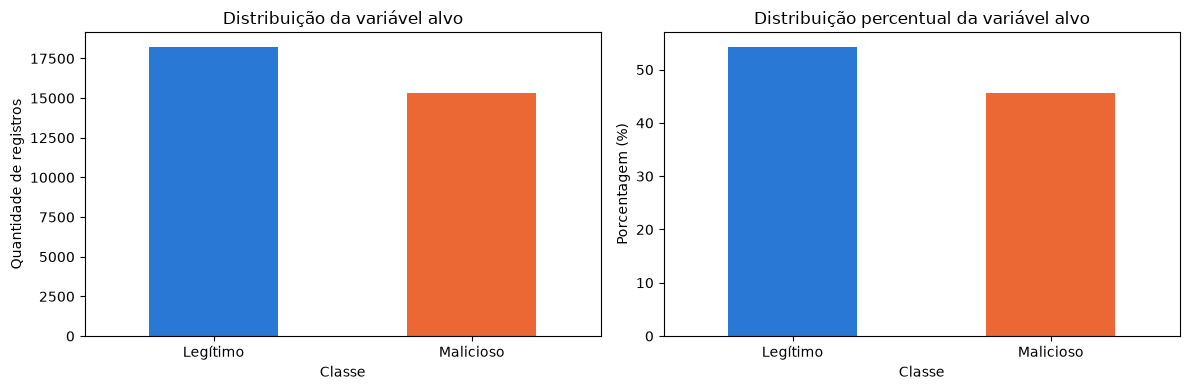

In [11]:
# Distribuição da variável alvo
contagem = df['is_malicious'].value_counts()
percentual = df['is_malicious'].value_counts(normalize = True) * 100

print(f'Número absoluto da variável alvo: \n{contagem}')
print(f'Percentual da variável alvo: \n{percentual}')

# Figuras
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

# Gráfico 1 - quantidade
contagem.plot(kind = "bar", ax = axes[0], color= [COR_PRIMARIA, COR_SECUNDARIA])
axes[0].set_title("Distribuição da variável alvo")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Quantidade de registros")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Legítimo", "Malicioso"], rotation = 0)

# Gráfico 2 - percentual
percentual.plot(kind = "bar", ax = axes[1], color= [COR_PRIMARIA, COR_SECUNDARIA])
axes[1].set_title("Distribuição percentual da variável alvo")
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("Porcentagem (%)")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Legítimo", "Malicioso"], rotation=0)

plt.tight_layout()
plt.show()

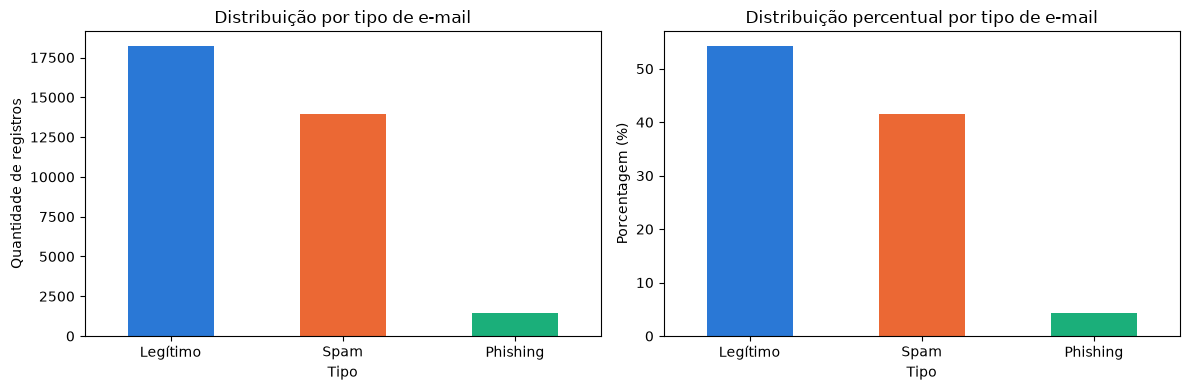

In [12]:
# Distinção entre legítimo, spam e phishing
df['tipo'] = np.select([df['is_malicious'] == 0, df['fonte'] == 'nazario'],
                       ['legitimo', 'phishing'],
                       default='spam')

contagem_por_tipo = df['tipo'].value_counts().reindex(['legitimo', 'spam', 'phishing'])
percentual_por_tipo = (df['tipo'].value_counts(normalize = True) * 100).reindex(['legitimo', 'spam', 'phishing'])

# Figuras
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

# Gráfico 1 - quantidade
contagem_por_tipo.plot(kind='bar', ax=axes[0], color=[COR_PRIMARIA, COR_SECUNDARIA, COR_TERCIARIA])
axes[0].set_title('Distribuição por tipo de e-mail')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('Quantidade de registros')
axes[0].set_xticklabels(['Legítimo', 'Spam', 'Phishing'], rotation=0)

# Gráfico 2 - percentual
percentual_por_tipo.plot(kind='bar', ax=axes[1], color=[COR_PRIMARIA, COR_SECUNDARIA, COR_TERCIARIA])
axes[1].set_title('Distribuição percentual por tipo de e-mail')
axes[1].set_xlabel('Tipo')
axes[1].set_ylabel('Porcentagem (%)')
axes[1].set_xticklabels(['Legítimo', 'Spam', 'Phishing'], rotation=0)

plt.tight_layout()
plt.show()

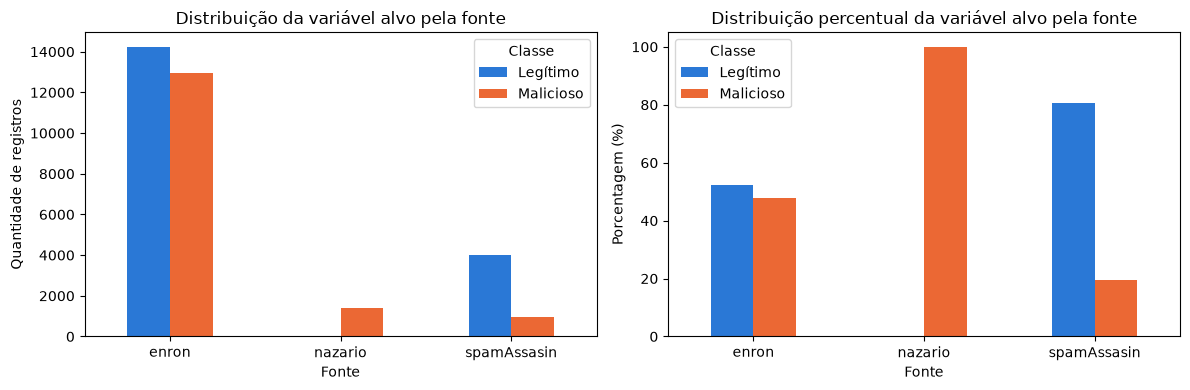

In [13]:
# Distribuição de classes da variável alvo pela fonte
contagem_por_classes = df.groupby('fonte')['is_malicious'].value_counts().unstack()
percentual_por_classes = (df.groupby('fonte')['is_malicious'].value_counts(normalize = True) * 100).unstack()

# Figuras
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

# Gráfico 1 - quantidade
contagem_por_classes.plot(kind = "bar", ax = axes[0], color = [COR_PRIMARIA, COR_SECUNDARIA])
axes[0].set_title("Distribuição da variável alvo pela fonte")
axes[0].set_xlabel("Fonte")
axes[0].set_ylabel("Quantidade de registros")
axes[0].tick_params(axis="x", rotation=0)
axes[0].set_xticks(range(len(contagem_por_classes)))
axes[0].legend(["Legítimo", "Malicioso"], title = 'Classe')

# Gráfico 2 - percentual
percentual_por_classes.plot(kind = "bar", ax = axes[1], color = [COR_PRIMARIA, COR_SECUNDARIA])
axes[1].set_title("Distribuição percentual da variável alvo pela fonte")
axes[1].set_xlabel("Fonte")
axes[1].set_ylabel("Porcentagem (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_xticks(range(len(percentual_por_classes)))
axes[1].legend(["Legítimo", "Malicioso"], title = 'Classe')


plt.tight_layout()
plt.show()

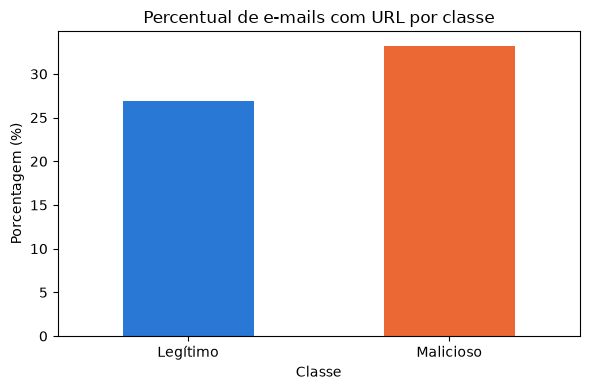

In [14]:
# percentual_urls de e-mails com URL, por classe
percentual_urls = df.groupby('is_malicious')['urls'].mean() * 100

fig, axes = plt.subplots(figsize=(6, 4))
percentual_urls.plot(kind='bar', ax=axes, color=[COR_PRIMARIA, COR_SECUNDARIA])
axes.set_title('Percentual de e-mails com URL por classe')
axes.set_xlabel('Classe')
axes.set_ylabel('Porcentagem (%)')
axes.set_xticks([0, 1])
axes.set_xticklabels(['Legítimo', 'Malicioso'], rotation=0)

plt.tight_layout()
plt.show()

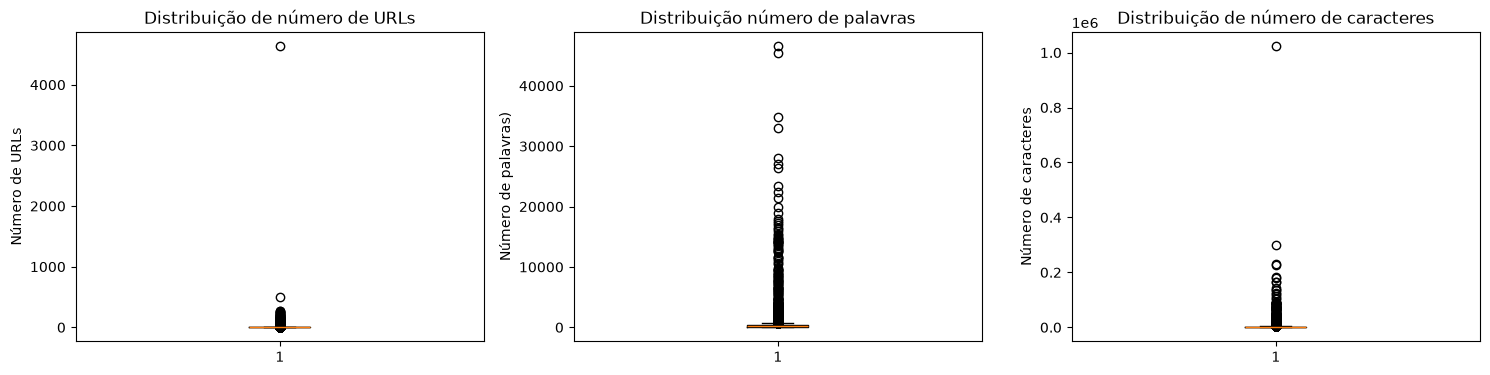

In [21]:
# Distribuição de num_urls

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].boxplot(df['num_urls'])
axes[0].set_title('Distribuição de número de URLs')
axes[0].set_ylabel('Número de URLs')

axes[1].boxplot(df['num_palavras'])
axes[1].set_title('Distribuição número de palavras')
axes[1].set_ylabel('Número de palavras)')

axes[2].boxplot(df['num_caracteres'])
axes[2].set_title('Distribuição de número de caracteres')
axes[2].set_ylabel('Número de caracteres')

plt.tight_layout()
plt.show()

Pode-se verificar que as três variáveis: *num_urls*, *num_palavras* e *num_caracteres* possuem *outliers* extremos, mesmo após a remoção de registros corrompidos no processamento inicial da base. Esses valores serão tratados na seção 3.

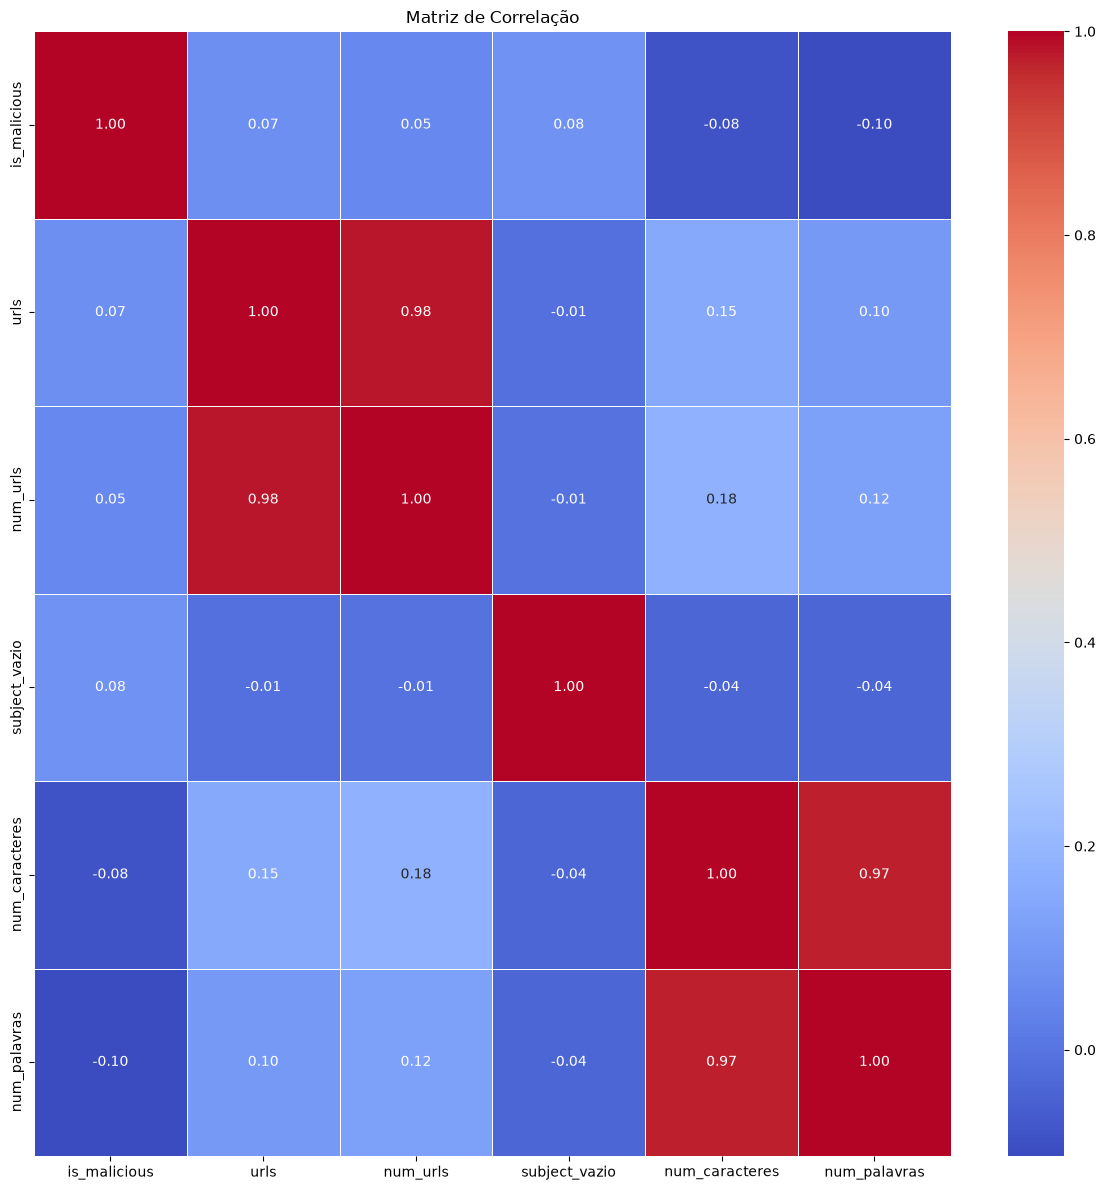

In [16]:
col_correlacao = ['is_malicious', 'urls', 'num_urls', 'subject_vazio', 'num_caracteres', 'num_palavras']

# Matriz de correlação
corr = df[col_correlacao].corr(method='spearman')

# Geração do heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação')

plt.tight_layout()
plt.show()

Podemos verificar a ausência de correlação forte entre as variáveis numéricas e a variável alvo, isso provavelmente se deve ao fato de que o sinal discriminativo está concentrado no texto de *subject* e *body*, não capturado nessa matriz.

Também foram observadas correlações fortes entre *urls* e *num_urls*, e entre *num_caracteres* e *num_palavras* o que era esperado, já que cada par é derivado da mesma lógica.

#### 3. Pré-processamento

##### 3.1 Tratamento de valores extremos residuais

Os valores extremos remanescentes, e-mails muito longos ou com muitas urls observados nos *boxplots*, correspondem a conteúdo real, como um *phishing* com uma lista extensa de destinatários, ou um digest de blog com centenas de links, e não a erros de extração. Por isso, as linhas foram mantidas, e o efeito dos valores extremos foi contido de duas formas: transformação logarítmica nas variáveis numéricas de contagem, e um limite de tamanho para o texto usado na vetorização.

In [17]:
# Transformação log1p para reduzir a influência de valores extremos, preservando o registro
df['log_num_urls'] = np.log1p(df['num_urls'])
df['log_num_caracteres'] = np.log1p(df['num_caracteres'])
df['log_num_palavras'] = np.log1p(df['num_palavras'])

# Comparação das novas variáveis
df[['num_urls', 'log_num_urls', 'num_caracteres', 'log_num_caracteres', 'num_palavras', 'log_num_palavras']].describe()

,num_urls,log_num_urls,num_caracteres,log_num_caracteres,num_palavras,log_num_palavras
count,33586.000000,33586.000000,3.358600e+04,33586.000000,33586.000000,33586.000000
mean,1.333949,0.366230,1.634824e+03,6.629495,303.877628,5.004245
std,26.440719,0.653048,7.498971e+03,1.166023,856.601105,1.150310
min,0.000000,0.000000,1.100000e+01,2.484907,1.000000,0.693147
25%,0.000000,0.000000,3.600000e+02,5.888878,70.000000,4.262680
50%,0.000000,0.000000,7.560000e+02,6.629363,149.000000,5.010635
75%,1.000000,0.693147,1.618000e+03,7.389564,320.000000,5.771441
max,4637.000000,8.442039,1.023577e+06,13.838815,46575.000000,10.748841


A partir da análise visual de extremos foram observados e-mails (aproximadamente 1,5% do total, concentrados na fonte SpamAssasin) cujo *body* preserva marcadores de estrutura MIME não decodificados na extração original dos dados, como *content-type* e *boundary*, em vez de conter apenas o texto legível do e-mail. Esses marcadores são ruído para a vetorização: não representam vocabulário relacionado a *phishing* ou *spam*, apenas artefatos do formato de transporte da mensagem.

Optou-se por não remover esses registros, pois removê-los introduziria viés de classe (a proporção de e-mails maliciosos entre eles é maior que a da base geral) e reduziria o tamanho útil do conjunto de dados. Também não se buscou decodificar o conteúdo MIME por completo, por estar fora do escopo desta análise.

A limpeza aplicada remove apenas os marcadores e seus valores imediatos, preservando o restante do texto ao redor de cada ocorrência. O resultado é salvo em uma coluna separada (*body_limpo*), sem sobrescrever o *body* original, para manter o texto bruto disponível para conferência.

In [18]:
# Limpeza leve de marcadores MIME
padrao_mime = r'content-type:\s*\S+(?:;\s*\S+)*|content-transfer-encoding:\s*\S+|mime-version:?\s*\S*|------=_\S*|boundary=\S*'
marcadores_iniciais = df['body'].str.contains(padrao_mime, regex=True, case=False).sum()
print(f'Marcadores MIME antes da limpeza: {marcadores_iniciais}')

# Criando nova coluna a partir da limpeza de body
df['body_limpo'] = df['body'].str.replace(padrao_mime, '', regex=True)

# Verificando a existência de marcadores MIME após a limpeza
marcadores_restantes = df['body_limpo'].str.contains(padrao_mime, regex=True, case=False).sum()
print(f'Marcadores MIME restantes após limpeza: {marcadores_restantes}')

Marcadores MIME antes da limpeza: 498
Marcadores MIME restantes após limpeza: 0


In [19]:
# Limite de caracteres usado apenas no momento de vetorizar o texto, para um documento longo não dominar as estatísticas
limite_caracteres = 20000
df['body_vetorizacao'] = df['body_limpo'].str.slice(0, limite_caracteres)

##### 3.2 Preparando os dados

In [22]:
# Texto final usado nos testes de validação e na vetorização
df['texto'] = df['subject'] + ' ' + df['body_vetorizacao']

In [37]:
# Pipeline de pré-processamento

# Pré-processamento de variáveis numéricas
num_transformador = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Pré-processamento de variáveis textuais
txt_transformador = Pipeline(steps=[
    ('vetor', TfidfVectorizer(max_features=50000, sublinear_tf=True))
])

# Montando pipeline
pre_processador = ColumnTransformer(
    transformers = [
        ('numerico', num_transformador, ['log_num_urls', 'log_num_palavras']),
        ('texto', txt_transformador, 'texto')
    ])

In [ ]:
# Medindo tamanho de vazamento entre as fontes

# 1) Split aleatório, estratificado só por classe

X = df[['texto', 'log_num_urls', 'log_num_palavras']]
y = df['is_malicious']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)


X_treino_processado = pre_processador.fit_transform(X_treino)
X_teste_processado = pre_processador.transform(X_teste)

modelo_reg_log = LogisticRegression(max_iter=1000).fit(X_treino_processado, y_treino)
y_pred = modelo_reg_log.predict(X_teste_processado)

print(accuracy_score(y_teste, y_pred))
print(f1_score(y_teste, y_pred))

# 2) Treina Enron e testa SpamAssassin
X_treino = df[df['fonte'] == 'enron']
X_teste = df[df['fonte'] == 'spamAssasin']



0.9846680559690384
0.9833306360252468
